# 의료영상 인공지능의 모든 것.

## 데이터셋 1.
### 심부전데이터셋 (Predicting Heart Failure 
- 출처: https://www.kaggle.com/datasets/whenamancodes/heart-failure-clinical-records

## 데이터셋 2
### 코로나 데이터셋  (COVID-19 Clinical Trials dataset)
- 출처: https://www.kaggle.com/datasets/parulpandey/covid19-clinical-trials-dataset


In [1]:
import pandas as pd
import numpy as np

path = './dataset/Heart Failure Clinical Records.csv'
h_origin_df= pd.read_csv(path)
h_origin_df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


In [2]:
# 데이터 컬럼 종류 및 결측치 확인
h_df = h_origin_df.copy()
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [3]:
# 데이터 사분위 확인 (개수, 평균, 표준편차, 최소, 최대, 중간)
h_df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [4]:
# NaN 누락된 비율 확인
# 필요 시 대채값을 상용하여 확인할 것.

for col in h_df.columns:
    pct_missing = np.mean(h_df[col].isnull())
    print(f"{col}- {round(pct_missing*100)}%")

age- 0%
anaemia- 0%
creatinine_phosphokinase- 0%
diabetes- 0%
ejection_fraction- 0%
high_blood_pressure- 0%
platelets- 0%
serum_creatinine- 0%
serum_sodium- 0%
sex- 0%
smoking- 0%
time- 0%
DEATH_EVENT- 0%


In [9]:
# 행 단위 중복 제거
h_df = h_df.drop_duplicates()

h_df.count()

age                         299
anaemia                     299
creatinine_phosphokinase    299
diabetes                    299
ejection_fraction           299
high_blood_pressure         299
platelets                   299
serum_creatinine            299
serum_sodium                299
sex                         299
smoking                     299
time                        299
DEATH_EVENT                 299
dtype: int64

In [18]:
h_df.DEATH_EVENT.unique()

array([1, 0])

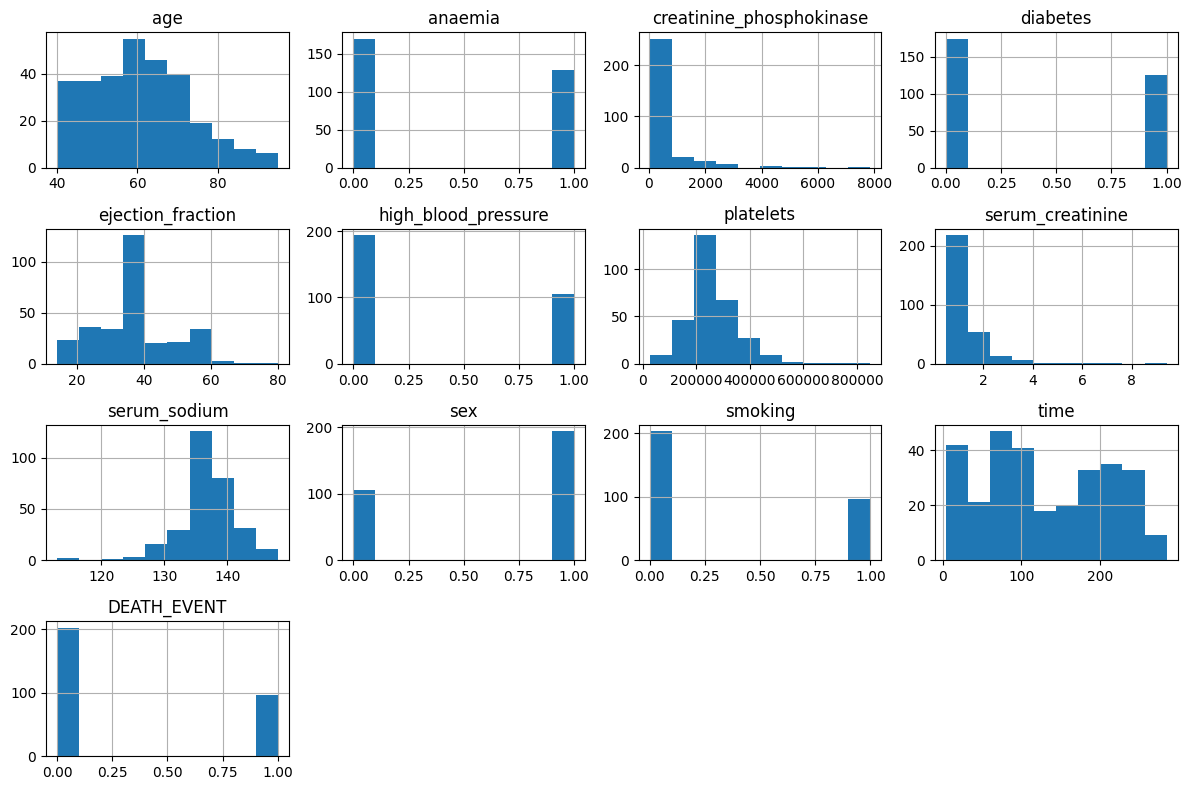

In [20]:
import matplotlib.pyplot as plt

# 히스토그램 출력
h_df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


In [28]:
# 상관관계 확인
import seaborn as sns

corr = h_df.corr()
corr

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


In [37]:
corr.DEATH_EVENT.sort_values(ascending=False)[1:]

corr[['DEATH_EVENT']].sort_values(by='DEATH_EVENT', ascending=False)[1:]

,DEATH_EVENT
serum_creatinine,0.294278
age,0.253729
high_blood_pressure,0.079351
anaemia,0.066270
creatinine_phosphokinase,0.062728
diabetes,-0.001943
sex,-0.004316
smoking,-0.012623
platelets,-0.049139
serum_sodium,-0.195204


<Axes: >

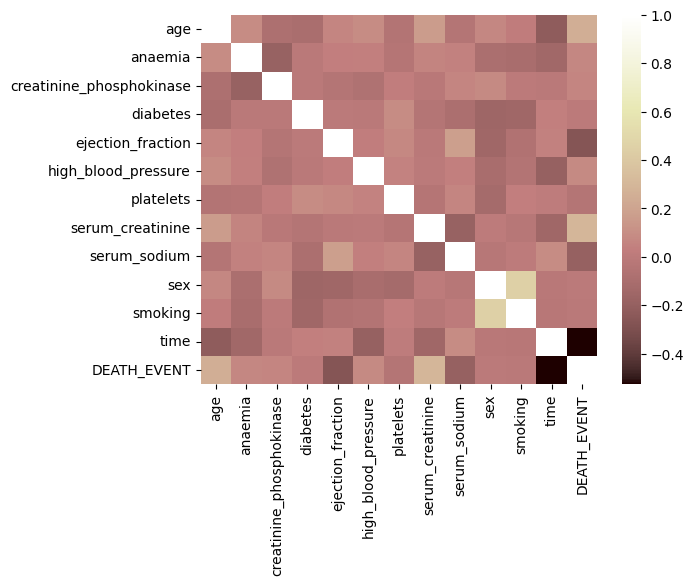

In [41]:
sns.heatmap(corr, cmap='pink')

In [42]:
h_df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [43]:
# 의료 데이터이기 때문에 언더 샘플링 진행 후 신뢰성 높게 실험하기로 결정.
# 언더샘플링
output0 = h_df[h_df.DEATH_EVENT==0].sample(96, random_state=124)
output1 = h_df[h_df.DEATH_EVENT==1]

h_df = pd.concat([output0, output1]).reset_index(drop=True)
display(h_df)

In [47]:
display(h_df.count())

age                         192
anaemia                     192
creatinine_phosphokinase    192
diabetes                    192
ejection_fraction           192
high_blood_pressure         192
platelets                   192
serum_creatinine            192
serum_sodium                192
sex                         192
smoking                     192
time                        192
DEATH_EVENT                 192
dtype: int64

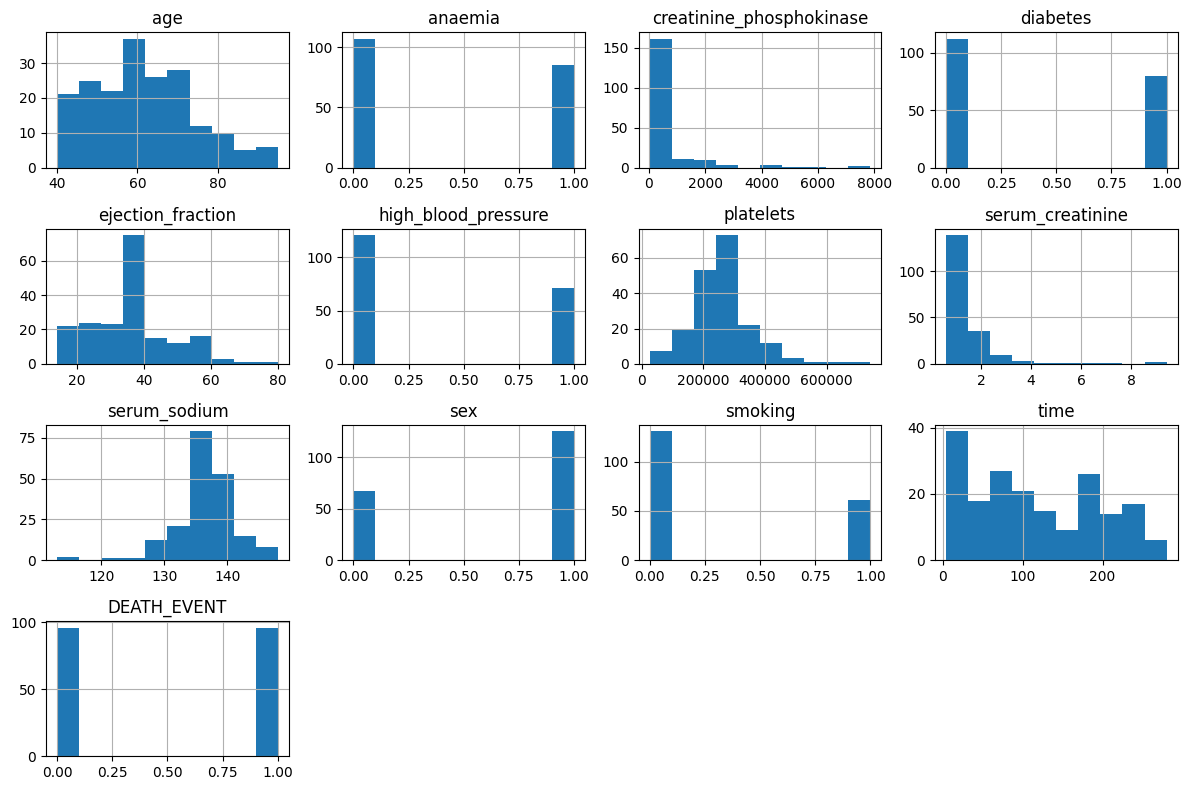

In [49]:
# 분포 확인
h_df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [66]:
# 이상치는 별도로 제거하지 않고 표준화도 진행하지 않은 상태로 실험진행.
from sklearn.model_selection import GridSearchCV, train_test_split

features, targets = h_df.iloc[:, :-1], h_df.iloc[:,-1]

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, stratify=targets, test_size=0.2, random_state=124)

In [67]:
# 모델선정 (이진분류 모델을 사용할 예정, 수치에 대한 값이 나눠져 있는 것 보다는 분류에 대하여 나눠져있는 것으로 판단)
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [68]:
# 정확도 확인
from sklearn.metrics import accuracy_score
print(dtc.max_depth)
print(dtc.min_samples_split)
print(dtc.feature_importances_)

prediction = dtc.predict(X_test)
acc_score = accuracy_score(y_test, prediction)
print("="*50)
print(f"최초 정확도: {round(acc_score*100,2)}%",)

None
2
[0.02942427 0.         0.06893295 0.04426287 0.08064132 0.
 0.04564984 0.21967891 0.11678059 0.01307245 0.         0.38155679]
최초 정확도: 69.23%


In [69]:
# 위에서 확인한 수치를 기준으로 교차검증 진행
parameters = {
    'max_depth': [5, 7],
    'min_samples_split': [10, 20 ,30] 
}

g_dtc = GridSearchCV(dtc, param_grid=parameters, cv=3, refit=True, return_train_score=True)
g_dtc.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [5, 7],
                         'min_samples_split': [10, 20, 30]},
             return_train_score=True)

In [70]:
prediction = g_dtc.predict(X_test)
acc_score = accuracy_score(y_test, prediction)
print("="*50)
print(f"교차 검증 이후 정확도: {round(acc_score*100,2)}%",)

교차 검증 이후 정확도: 79.49%


In [71]:
# 오차 행렬 확인
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def get_evaluation(y_test, prediction, classifier=None, X_test=None):
    confusion = confusion_matrix(y_test, prediction)
    accuracy = accuracy_score(y_test , prediction)
    precision = precision_score(y_test , prediction)
    recall = recall_score(y_test , prediction)
    f1 = f1_score(y_test, prediction)
    auc = roc_auc_score(y_test, prediction)
    
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, ROC-AUC: {4:.4f}'.format(accuracy, precision, recall, f1, auc))
    print("#" * 80)
    
    if classifier is not None and  X_test is not None:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
        titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

        for (title, normalize), ax in zip(titles_options, axes.flatten()):
            disp = ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax=ax, cmap=plt.cm.Blues, normalize=normalize)
            disp.ax_.set_title(title)
        plt.show()

오차 행렬
[[16  4]
 [ 4 15]]
정확도: 0.7949, 정밀도: 0.7895, 재현율: 0.7895, F1: 0.7895, ROC-AUC: 0.7947
################################################################################


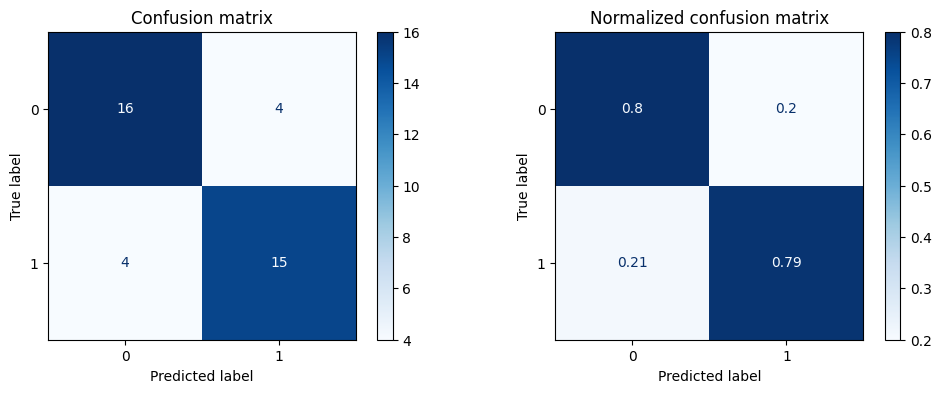

In [72]:
get_evaluation(y_test, prediction, g_dtc, X_test)

# 결과가 너무 적은 상태에서 높은 판단 수치를 나타내는 것으로 보임, 추가적인 데이터 수집 필요